In [115]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/veerkukreti/trading-datasets/historical_data.csv
/kaggle/input/datasets/veerkukreti/trading-datasets/fear_greed_index.csv


In [116]:
fg= pd.read_csv("/kaggle/input/datasets/veerkukreti/trading-datasets/fear_greed_index.csv")
hd= pd.read_csv("/kaggle/input/datasets/veerkukreti/trading-datasets/historical_data.csv")

In [117]:
fg.head(100)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05
...,...,...,...,...
95,1525930200,63,Greed,2018-05-10
96,1526016600,41,Fear,2018-05-11
97,1526103000,44,Fear,2018-05-12
98,1526189400,40,Fear,2018-05-13


In [118]:
hd.head(100)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.000000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.000000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.000000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.000000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.000000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,9.0642,82.02,743.45,SELL,03-12-2024 15:22,4189.888602,Sell,101.447367,0x125ea070e5b6af24d28e04184f784a02018f001d1acb...,52209955900,True,0.260205,3.910000e+14,1.730000e+12
96,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,9.0642,97.70,885.57,SELL,03-12-2024 15:22,4107.868602,Sell,120.841353,0x125ea070e5b6af24d28e04184f784a02018f001d1acb...,52209955900,True,0.309950,5.680000e+14,1.730000e+12
97,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,9.0613,98.00,888.01,SELL,03-12-2024 15:22,4010.168602,Sell,120.928211,0x125ea070e5b6af24d28e04184f784a02018f001d1acb...,52209955900,True,0.310802,1.860000e+13,1.730000e+12
98,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,9.0611,82.02,743.19,SELL,03-12-2024 15:22,3912.168602,Sell,101.193105,0x125ea070e5b6af24d28e04184f784a02018f001d1acb...,52209955900,True,0.260116,8.570000e+14,1.730000e+12


In [119]:
fg.describe()

,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


In [120]:
hd.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [121]:
hd.isnull().sum()
fg.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [122]:
hd["date"] = pd.to_datetime(hd["Timestamp"], unit="ms").dt.date

In [123]:
fg.columns


Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [124]:
df = hd.merge(
    fg[["date", "classification", "value"]],
    on="date",
    how="left"
)

In [125]:
hd["date"] = pd.to_datetime(hd["Timestamp"], unit="ms").dt.date
fg["date"] = pd.to_datetime(fg["timestamp"], unit="s").dt.date

In [126]:
hd["date"].head()
fg["date"].head()

0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: date, dtype: object

In [127]:
daily_pnl = df.groupby(["Account","date"])["Closed PnL"].sum().reset_index()
trade_freq = df.groupby(["Account","date"]).size().reset_index(name="trades_per_day")
avg_trade_size = df.groupby(["Account","date"])["Size USD"].mean().reset_index()

In [128]:
df["win"] = df["Closed PnL"] > 0

win_rate = df.groupby(["Account","date"])["win"].mean().reset_index()

In [129]:
metrics = daily_pnl.merge(trade_freq,on=["Account","date"])
metrics = metrics.merge(avg_trade_size,on=["Account","date"])
metrics = metrics.merge(win_rate,on=["Account","date"])
metrics = metrics.merge(fg[["date","classification"]], on="date")


In [130]:
Q1 = metrics["Closed PnL"].quantile(0.25)
Q3 = metrics["Closed PnL"].quantile(0.75)

IQR = Q3 - Q1

metrics_filtered = metrics[
    (metrics["Closed PnL"] >= Q1 - 1.5*IQR) &
    (metrics["Closed PnL"] <= Q3 + 1.5*IQR)
]

In [131]:
metrics.describe()

,Closed PnL,trades_per_day,Size USD,win
count,7.700000e+01,77.000000,77.000000,77.000000
mean,1.327954e+05,2393.025974,5565.928192,0.377234
std,3.117880e+05,4227.889722,6663.913468,0.233793
min,-3.275059e+05,2.000000,34.916667,0.000000
25%,1.793160e+03,190.000000,1684.202580,0.263610
50%,3.699337e+04,763.000000,2936.198591,0.384864
75%,1.164123e+05,3356.000000,6742.719767,0.474443
max,1.927736e+06,26651.000000,31941.660000,1.000000


In [132]:
from scipy.stats import skew, kurtosis

cols = ["Closed PnL","trades_per_day","Size USD"]

for col in cols:
    print(col)
    print("Skewness:", skew(metrics[col], nan_policy='omit'))
    print("Kurtosis:", kurtosis(metrics[col], nan_policy='omit'))
    print()

Closed PnL
Skewness: 3.7844617043239084
Kurtosis: 16.480623151744105

trades_per_day
Skewness: 3.7944659583292957
Kurtosis: 16.987285239243512

Size USD
Skewness: 2.1199434364022065
Kurtosis: 4.201962936213463



the skewness and kurtosis are too large and thus we will use log to suppress the larger values and make the data's skew come down to around 0-1

In [133]:

metrics["log_pnl"] = np.sign(metrics["Closed PnL"]) * np.log1p(np.abs(metrics["Closed PnL"]))
metrics["log_trades"] = np.log1p(metrics["trades_per_day"])
metrics["log_size_usd"] = np.log1p(metrics["Size USD"])

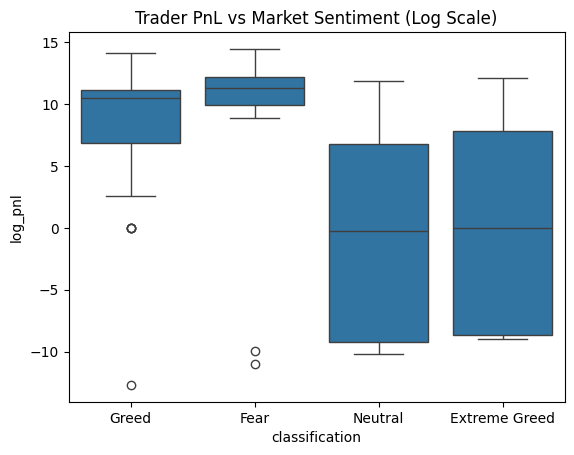

In [134]:
sns.boxplot(data=metrics, x="classification", y="log_pnl")
plt.title("Trader PnL vs Market Sentiment (Log Scale)")
plt.show()

* Fear days have the highest median log-PnL.
* Greed also shows positive profitability but slightly lower.
* Neutral and Extreme Greed have medians around zero or negative.
* Loss variability is much larger during Neutral and Extreme Greed.

Trader profitability appears highest during Fear sentiment regimes, suggesting that volatile market conditions create more opportunities for profitable trading strategies.

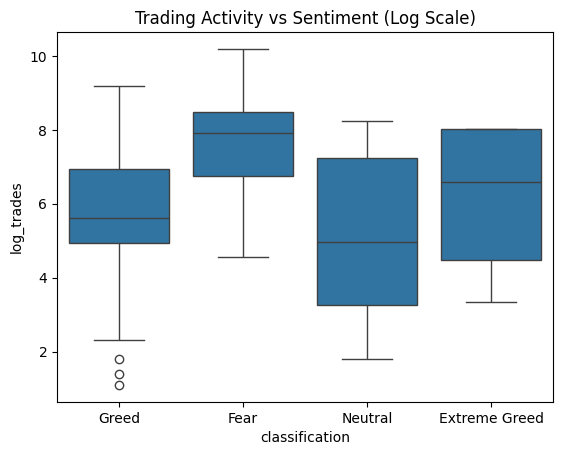

In [135]:
sns.boxplot(data=metrics, x="classification", y="log_trades")
plt.title("Trading Activity vs Sentiment (Log Scale)")
plt.show()

* Fear has the highest median trading frequency.
* Extreme Greed also shows elevated activity.\
* Neutral markets show the lowest trading activity.
* Greed sits in the middle

  Trading frequency increases significantly during Fear regimes, indicating traders react to volatility with more frequent execution.

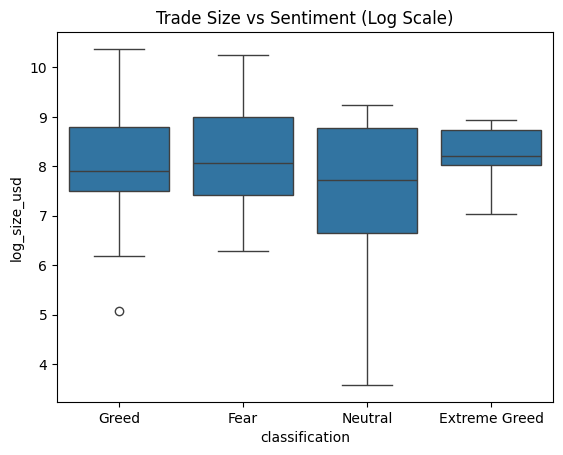

In [136]:
sns.boxplot(data=metrics, x="classification", y="log_size_usd")
plt.title("Trade Size vs Sentiment (Log Scale)")
plt.show()

* Trade size is relatively stable across sentiment regimes.
* Extreme Greed shows slightly larger median trade size.
* Neutral markets show smaller and more variable trade sizes.

Traders respond to market sentiment primarily by adjusting trade frequency rather than dramatically altering position size.

Insight 1:

Trader profitability tends to increase during Fear sentiment regimes, likely due to heightened market volatility creating exploitable price movements.

Insight 2:

Trading activity peaks during Fear periods, indicating traders react to uncertainty with increased execution frequency.

Insight 3:

Trade sizes remain relatively stable across sentiment regimes, suggesting traders adjust activity levels rather than exposure size when responding to sentiment.


In [137]:
top_traders = hd.groupby("Account")["Closed PnL"].sum().sort_values(ascending=False).head(10)

In [138]:
metrics["frequency_segment"] = pd.qcut(
    metrics["trades_per_day"],3,
    labels=["Low","Medium","High"]
)

In [139]:
metrics["size_segment"] = pd.qcut(
    metrics["Size USD"],3,
    labels=["Small","Medium","Large"]
)

In [140]:
from scipy.stats import kruskal

fear = metrics[metrics["classification"]=="Fear"]["log_pnl"]
greed = metrics[metrics["classification"]=="Greed"]["log_pnl"]
neutral = metrics[metrics["classification"]=="Neutral"]["log_pnl"]
extreme_greed = metrics[metrics["classification"]=="Extreme Greed"]["log_pnl"]

kruskal(fear, greed, neutral, extreme_greed)

KruskalResult(statistic=np.float64(13.201122856842344), pvalue=np.float64(0.004221250231863968))

In [141]:
metrics.groupby("classification")[["log_pnl","log_trades","log_size_usd"]].median()

,log_pnl,log_trades,log_size_usd
classification,,,
Extreme Greed,0.000000,6.594413,8.210344
Fear,11.285035,7.918986,8.073679
Greed,10.490589,5.619981,7.904882
Neutral,-0.271193,4.957955,7.718921


IndexError: index 0 is out of bounds for axis 0 with size 0

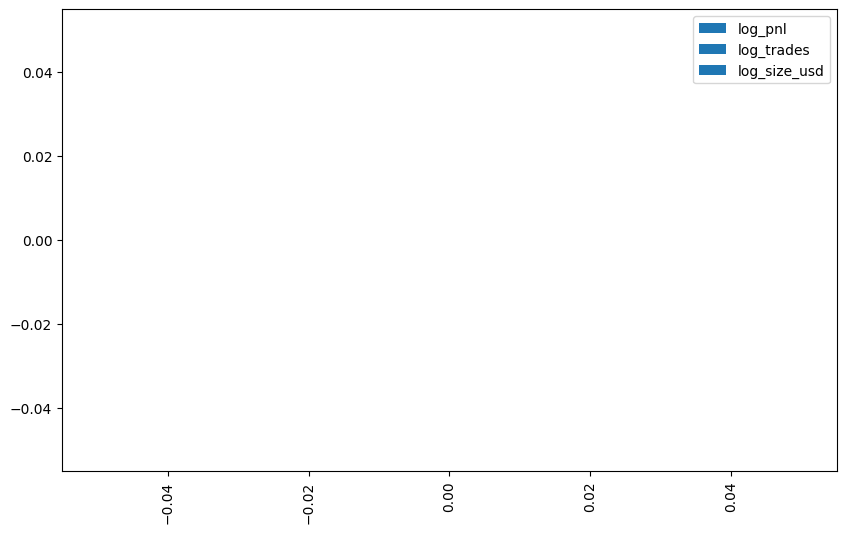

In [143]:
df["log_pnl"] = np.sign(df["Closed PnL"]) * np.log1p(np.abs(df["Closed PnL"]))
df["log_size_usd"] = np.log1p(df["Size USD"])

In [144]:
trades_per_day = df.groupby(["Account","date"]).size().reset_index(name="trades_per_day")

df = df.merge(trades_per_day, on=["Account","date"], how="left")

In [148]:
df["log_trades"] = np.log1p(df["trades_per_day"])

In [149]:
df.groupby("classification")[["log_pnl","log_trades","log_size_usd"]].median()

,log_pnl,log_trades,log_size_usd
classification,,,


In [151]:
hd["date"].min(), hd["date"].max()

(datetime.date(2023, 3, 28), datetime.date(2025, 6, 15))

In [152]:
fg["date"].min(), fg["date"].max()

(datetime.date(2018, 2, 1), datetime.date(2025, 5, 2))

In [154]:
hd["date"].head()

0    2024-10-27
1    2024-10-27
2    2024-10-27
3    2024-10-27
4    2024-10-27
Name: date, dtype: object

In [155]:
hd["date"].value_counts().head()

date
2025-02-19    133871
2024-10-27     35241
2025-06-15     26961
2024-07-03      7141
2024-03-09      6962
Name: count, dtype: int64

In [158]:
fg["date"].head()


0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: date, dtype: object

In [157]:
fg["date"].tail()

2639    2025-04-28
2640    2025-04-29
2641    2025-04-30
2642    2025-05-01
2643    2025-05-02
Name: date, dtype: object